# MMM Stress Test #5 — Weak Media Signal

> **One simple question:** What happens when media explains only a tiny fraction of total revenue?

This notebook runs a controlled synthetic experiment to answer that question.

**Setup:**
- 156 weeks of synthetic data
- 3 marketing channels: Meta, Search, TV
- True ROAS is fixed and known: Meta = 2.0, Search = 5.0, TV = 1.5
- Revenue has trend, seasonality, promotions, and media contributions
- A simple OLS model with the correct controls is fitted
- Repeated across 300+ simulations per condition

**Stress variable:** The baseline multiplier.

The baseline multiplier scales the non-media component of revenue upward — from 1× (media is ~20% of revenue) to 32× (media is ~1% of revenue). The causal mechanism — the true ROAS — never changes. Only the signal-to-noise ratio for media identification changes. As the baseline grows, media spend becomes a smaller and smaller fraction of total revenue variation, making it harder for the model to isolate the marginal effect of each channel.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams['figure.dpi'] = 120

## 1. Configuration

The key variable in this experiment is the **baseline multiplier**.

The baseline represents all revenue that is not caused by marketing: organic demand, seasonality, trend, promotions, and structural intercept. By scaling it upward, we make media a progressively smaller fraction of total revenue.

| Multiplier | Approximate media share of revenue |
|---|---|
| 1× | ~20% |
| 2× | ~11% |
| 4× | ~6% |
| 8× | ~3% |
| 16× | ~1.5% |
| 32× | ~0.8% |

The true ROAS (Meta = 2.0, Search = 5.0, TV = 1.5) never changes across any condition. Only the model's ability to *see* the media signal in the data changes.

In [2]:
N_WEEKS = 156

TRUE_ROAS = {
    "meta": 2.0,
    "search": 5.0,
    "tv": 1.5
}

NOISE_SD = 60_000

BASELINE_MULTIPLIERS = [1.0, 2.0, 4.0, 8.0, 16.0, 32.0]

print(f"N_WEEKS              : {N_WEEKS}")
print(f"TRUE_ROAS            : {TRUE_ROAS}")
print(f"NOISE_SD             : {NOISE_SD:,}")
print(f"BASELINE_MULTIPLIERS : {BASELINE_MULTIPLIERS}")

N_WEEKS              : 156
TRUE_ROAS            : {'meta': 2.0, 'search': 5.0, 'tv': 1.5}
NOISE_SD             : 60,000
BASELINE_MULTIPLIERS : [1.0, 2.0, 4.0, 8.0, 16.0, 32.0]


## 2. Generate synthetic marketing data

**Revenue formula:**

```
revenue = baseline + 2.0 * meta_spend + 5.0 * search_spend + 1.5 * tv_spend + noise
```

where:

```
baseline = multiplier * (2_000_000 + 4_000*t + 500_000*sin(2πt/52) + 150_000*cos(2πt/52) + 400_000*promo)
```

The `baseline_multiplier` scales the entire non-media baseline upward. Media ROAS coefficients are always 2.0, 5.0, and 1.5. As the multiplier grows, the absolute size of the media contribution stays the same, but becomes a smaller signal relative to total revenue variation. This is exactly the weak signal problem in MMM: the model can explain most of the revenue from trend and seasonality, but the media coefficients become hard to pin down because they explain relatively little of the remaining variance.

In [3]:
def generate_data(baseline_multiplier=1.0, seed=42, n_weeks=N_WEEKS, noise_sd=NOISE_SD):
    """Generate synthetic MMM dataset with known true ROAS.

    The baseline_multiplier scales the non-media revenue component.
    Media ROAS coefficients are always: Meta=2.0, Search=5.0, TV=1.5.
    """
    rng = np.random.default_rng(seed)

    t = np.arange(n_weeks)
    promo = rng.binomial(1, 0.12, size=n_weeks).astype(float)
    sin52 = np.sin(2 * np.pi * t / 52)
    cos52 = np.cos(2 * np.pi * t / 52)

    # Baseline scaled by multiplier; media effects are unchanged
    baseline = baseline_multiplier * (
        2_000_000
        + 4_000 * t
        + 500_000 * sin52
        + 150_000 * cos52
        + 400_000 * promo
    )

    # Correlated Meta / Search shocks
    cov = [[1.0, 0.20], [0.20, 1.0]]
    shocks = rng.multivariate_normal([0.0, 0.0], cov, size=n_weeks)

    meta_spend   = np.clip(55_000 + 22_000 * shocks[:, 0], 5_000, None)
    search_spend = np.clip(42_000 + 16_000 * shocks[:, 1], 5_000, None)
    tv_spend     = np.clip(90_000 + 45_000 * rng.normal(size=n_weeks), 0, None)

    true_meta_incremental   = TRUE_ROAS["meta"]   * meta_spend
    true_search_incremental = TRUE_ROAS["search"] * search_spend
    true_tv_incremental     = TRUE_ROAS["tv"]     * tv_spend

    noise = rng.normal(0, noise_sd, size=n_weeks)

    revenue = (
        baseline
        + true_meta_incremental
        + true_search_incremental
        + true_tv_incremental
        + noise
    )

    df = pd.DataFrame({
        "week":                   t,
        "revenue":                revenue,
        "baseline":               baseline,
        "meta_spend":             meta_spend,
        "search_spend":           search_spend,
        "tv_spend":               tv_spend,
        "promo":                  promo,
        "trend":                  t,
        "sin52":                  sin52,
        "cos52":                  cos52,
        "true_meta_incremental":  true_meta_incremental,
        "true_search_incremental": true_search_incremental,
        "true_tv_incremental":    true_tv_incremental,
    })

    total_media_inc = (
        true_meta_incremental.sum()
        + true_search_incremental.sum()
        + true_tv_incremental.sum()
    )
    media_share = total_media_inc / revenue.sum()
    print(f"  baseline_multiplier={baseline_multiplier:.1f}  |  media share of revenue = {media_share:.2%}")

    return df

## 3. Inspect one clean dataset

Before running any stress test, inspect a single dataset at the baseline condition (`baseline_multiplier = 1.0`). We expect:
- Media share of revenue around 20%
- Meta / Search correlation around 0.20
- TV uncorrelated with other channels
- Revenue has a clear upward trend and seasonal pattern

  baseline_multiplier=1.0  |  media share of revenue = 16.10%

--- First 5 rows ---


,week,revenue,baseline,meta_spend,search_spend,tv_spend,promo,trend,sin52,cos52,true_meta_incremental,true_search_incremental,true_tv_incremental
0,0,"2,646,763.1220","2,150,000.0000","31,317.5001","60,556.7494","76,806.3786",0.0000,0,0.0000,1.0000,"62,635.0001","302,783.7471","115,209.5679"
1,1,"2,771,620.3580","2,213,174.6712","39,106.1165","50,330.0613","177,175.4023",0.0000,1,0.1205,0.9927,"78,212.2330","251,650.3064","265,763.1035"
2,2,"2,852,199.8979","2,273,299.1048","79,995.8929","36,197.2555","139,769.7016",0.0000,2,0.2393,0.9709,"159,991.7857","180,986.2774","209,654.5525"
3,3,"2,763,793.8047","2,329,554.8799","81,537.4883","46,622.4479","46,705.8998",0.0000,3,0.3546,0.9350,"163,074.9765","233,112.2394","70,058.8496"
4,4,"2,611,810.8612","2,381,179.9899","30,157.2696","7,308.8622","105,646.8804",0.0000,4,0.4647,0.8855,"60,314.5393","36,544.3108","158,470.3205"



--- Spend correlation matrix ---


,meta_spend,search_spend,tv_spend
meta_spend,1.0000,0.2198,-0.1186
search_spend,0.2198,1.0000,-0.0249
tv_spend,-0.1186,-0.0249,1.0000



--- Ground truth (multiplier=1.0) ---


,channel,true_roas,total_spend,total_incremental,implied_roas
0,meta,2.0000,"8,569,233.5674","17,138,467.1348",2.0000
1,search,5.0000,"6,471,461.1314","32,357,305.6569",5.0000
2,tv,1.5000,"13,738,449.6821","20,607,674.5231",1.5000



Media share of total revenue (multiplier=1.0): 16.10%


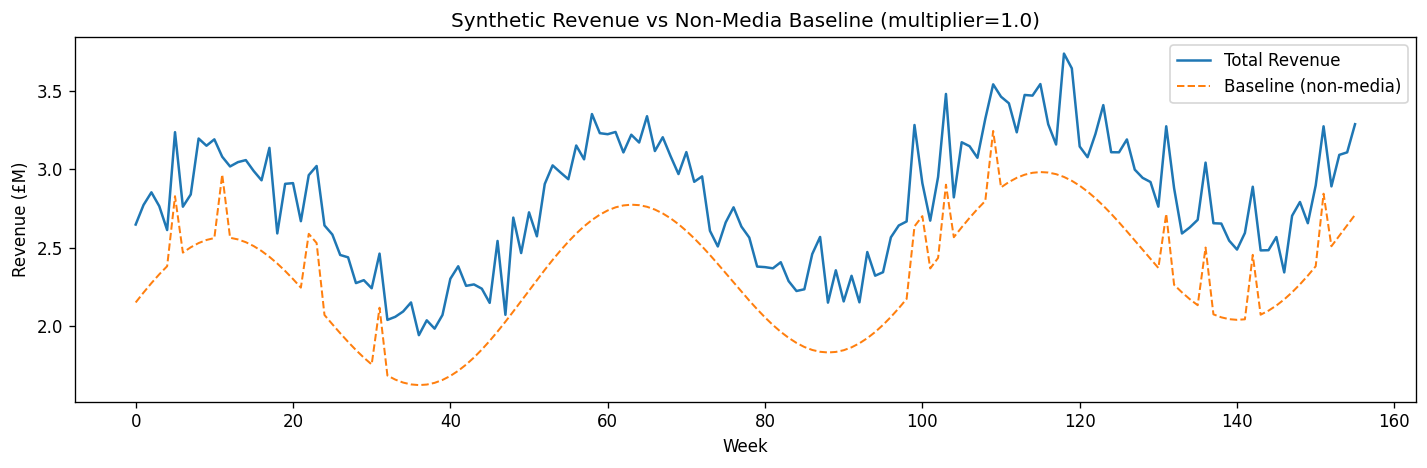

In [4]:
clean_df = generate_data(baseline_multiplier=1.0, seed=42)

print("\n--- First 5 rows ---")
display(clean_df.head())

print("\n--- Spend correlation matrix ---")
display(clean_df[["meta_spend", "search_spend", "tv_spend"]].corr())

print("\n--- Ground truth (multiplier=1.0) ---")
truth_rows = []
for ch in ["meta", "search", "tv"]:
    total_spend = clean_df[f"{ch}_spend"].sum()
    total_inc   = clean_df[f"true_{ch}_incremental"].sum()
    implied_roas = total_inc / total_spend
    truth_rows.append({
        "channel":        ch,
        "true_roas":      TRUE_ROAS[ch],
        "total_spend":    total_spend,
        "total_incremental": total_inc,
        "implied_roas":   implied_roas
    })
truth_table = pd.DataFrame(truth_rows)
display(truth_table)

total_media_inc = (
    clean_df["true_meta_incremental"].sum()
    + clean_df["true_search_incremental"].sum()
    + clean_df["true_tv_incremental"].sum()
)
media_share_clean = total_media_inc / clean_df["revenue"].sum()
print(f"\nMedia share of total revenue (multiplier=1.0): {media_share_clean:.2%}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(clean_df["week"], clean_df["revenue"] / 1e6, label="Total Revenue", linewidth=1.5)
ax.plot(clean_df["week"], clean_df["baseline"] / 1e6, label="Baseline (non-media)", linestyle="--", linewidth=1.2)
ax.set_xlabel("Week")
ax.set_ylabel("Revenue (£M)")
ax.set_title("Synthetic Revenue vs Non-Media Baseline (multiplier=1.0)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Fit the simplest possible MMM

OLS regression with the correct set of controls:
- Media spends: `meta_spend`, `search_spend`, `tv_spend`
- Trend: `trend` (week index)
- Seasonality: `sin52`, `cos52`
- Promotions: `promo`

This is the best-case OLS model — no misspecification, no omitted variables, no wrong functional form. Any ROAS recovery failures are purely due to the data environment, not model error.

In [5]:
def fit_model(df):
    """Fit OLS MMM with correct controls. Returns fitted statsmodels result."""
    features = ["meta_spend", "search_spend", "tv_spend", "trend", "sin52", "cos52", "promo"]
    X = sm.add_constant(df[features])
    y = df["revenue"]
    model = sm.OLS(y, X).fit()
    return model


# Fit to the clean dataset
clean_model = fit_model(clean_df)
print(f"R² on clean dataset (multiplier=1.0): {clean_model.rsquared:.4f}")

# ROAS estimates vs truth
channel_coef_map = {"meta": "meta_spend", "search": "search_spend", "tv": "tv_spend"}
single_run_rows = []
for ch, coef_name in channel_coef_map.items():
    true_roas = TRUE_ROAS[ch]
    est_roas  = clean_model.params[coef_name]
    rel_err   = abs(est_roas - true_roas) / true_roas
    single_run_rows.append({
        "channel":        ch,
        "true_roas":      true_roas,
        "estimated_roas": est_roas,
        "relative_error": rel_err
    })

single_run_df = pd.DataFrame(single_run_rows)
print("\n--- Single run ROAS recovery (multiplier=1.0) ---")
display(single_run_df)

R² on clean dataset (multiplier=1.0): 0.9761

--- Single run ROAS recovery (multiplier=1.0) ---


,channel,true_roas,estimated_roas,relative_error
0,meta,2.0000,1.8756,0.0622
1,search,5.0000,5.2184,0.0437
2,tv,1.5000,1.5988,0.0659


## 5. Do not trust one simulation

A single OLS run on a single synthetic dataset is not evidence of anything. The spend draws are random, the noise is random, and the promotions are random. One lucky run can look perfect; one unlucky run can look terrible.

**Monte Carlo reasoning:** Run the same DGP 300–500 times per condition, each with a different random seed. Summarise the *distribution* of estimated ROAS across simulations. This tells us what we can expect on average and how much uncertainty we face in practice.

The question is not "did OLS recover ROAS on this one dataset?" but "what fraction of the time does OLS recover ROAS to within 50% of the truth, and how does that fraction change as the baseline multiplier grows?"

In [6]:
def run_one_simulation(baseline_multiplier, seed):
    """Generate data, fit OLS, return per-channel result rows."""
    df    = generate_data(baseline_multiplier=baseline_multiplier, seed=seed,
                          n_weeks=N_WEEKS, noise_sd=NOISE_SD)
    model = fit_model(df)

    total_media_inc = (
        df["true_meta_incremental"].sum()
        + df["true_search_incremental"].sum()
        + df["true_tv_incremental"].sum()
    )
    media_share = total_media_inc / df["revenue"].sum()
    r2          = model.rsquared

    channel_coef_map = {"meta": "meta_spend", "search": "search_spend", "tv": "tv_spend"}
    rows = []
    for ch, coef_name in channel_coef_map.items():
        true_roas = TRUE_ROAS[ch]
        est_roas  = model.params[coef_name]
        rel_err   = abs(est_roas - true_roas) / true_roas

        # 90% confidence interval
        ci        = model.conf_int(alpha=0.10)
        ci_low    = ci.loc[coef_name, 0]
        ci_high   = ci.loc[coef_name, 1]
        covered   = float(ci_low <= true_roas <= ci_high)

        rows.append({
            "baseline_multiplier": baseline_multiplier,
            "media_share":         media_share,
            "seed":                seed,
            "channel":             ch,
            "true_roas":           true_roas,
            "estimated_roas":      est_roas,
            "relative_error":      rel_err,
            "ci_low":              ci_low,
            "ci_high":             ci_high,
            "covered_truth":       covered,
            "r2":                  r2
        })
    return rows

## 6. Clean-case Monte Carlo (multiplier = 1.0, N = 500)

Before stressing the model, establish what good looks like. At multiplier = 1.0, media is around 20% of revenue. This is the standard "clean" condition from Stress Test #00.

We expect:
- Median estimated ROAS close to true ROAS
- 90% CI coverage near 90%
- Probability of >50% relative error low (ideally <5%)

In [7]:
N_CLEAN_SIMS = 500

print(f"Running {N_CLEAN_SIMS} clean-case simulations (baseline_multiplier=1.0) ...")
clean_rows = []
for sim_id in range(N_CLEAN_SIMS):
    seed = 42 + sim_id
    clean_rows.extend(run_one_simulation(baseline_multiplier=1.0, seed=seed))

clean_results = pd.DataFrame(clean_rows)
print(f"\nTotal rows: {len(clean_results)}")

clean_scorecard = (
    clean_results
    .groupby("channel")
    .agg(
        media_share       = ("media_share",    "mean"),
        true_roas         = ("true_roas",      "first"),
        median_est_roas   = ("estimated_roas", "median"),
        median_rel_error  = ("relative_error", "median"),
        prob_over_50pct   = ("relative_error", lambda x: (x > 0.50).mean()),
        coverage_90pct    = ("covered_truth",  "mean"),
        mean_r2           = ("r2",             "mean")
    )
    .reset_index()
)
clean_scorecard["prob_over_50pct_pct"]  = clean_scorecard["prob_over_50pct"]  * 100
clean_scorecard["coverage_90pct_pct"]   = clean_scorecard["coverage_90pct"]   * 100
clean_scorecard["media_share_pct"]      = clean_scorecard["media_share"]      * 100

print("\n--- Clean-case scorecard (baseline_multiplier=1.0, N=500) ---")
display(clean_scorecard)

Running 500 clean-case simulations (baseline_multiplier=1.0) ...
  baseline_multiplier=1.0  |  media share of revenue = 16.10%
  baseline_multiplier=1.0  |  media share of revenue = 15.69%
  baseline_multiplier=1.0  |  media share of revenue = 16.08%
  baseline_multiplier=1.0  |  media share of revenue = 16.53%
  baseline_multiplier=1.0  |  media share of revenue = 16.26%
  baseline_multiplier=1.0  |  media share of revenue = 15.94%
  baseline_multiplier=1.0  |  media share of revenue = 16.76%
  baseline_multiplier=1.0  |  media share of revenue = 16.01%
  baseline_multiplier=1.0  |  media share of revenue = 16.08%
  baseline_multiplier=1.0  |  media share of revenue = 16.85%
  baseline_multiplier=1.0  |  media share of revenue = 16.25%
  baseline_multiplier=1.0  |  media share of revenue = 15.88%
  baseline_multiplier=1.0  |  media share of revenue = 16.53%
  baseline_multiplier=1.0  |  media share of revenue = 16.23%
  baseline_multiplier=1.0  |  media share of revenue = 15.83%
  bas

,channel,media_share,true_roas,median_est_roas,median_rel_error,prob_over_50pct,coverage_90pct,mean_r2,prob_over_50pct_pct,coverage_90pct_pct,media_share_pct
0,meta,0.1619,2.0000,2.0101,0.0695,0.0000,0.9360,0.9797,0.0000,93.6000,16.1908
1,search,0.1619,5.0000,4.9915,0.0464,0.0000,0.9040,0.9797,0.0000,90.4000,16.1908
2,tv,0.1619,1.5000,1.4986,0.0496,0.0000,0.9060,0.9797,0.0000,90.6000,16.1908


## 7. The actual stress test — vary baseline multiplier

Now run the full stress test across all six baseline multiplier levels.

**What changes across conditions:**
- The baseline multiplier (1×, 2×, 4×, 8×, 16×, 32×)
- The media share of total revenue (falls from ~20% to ~1%)

**What stays identical across conditions:**
- True ROAS: Meta=2.0, Search=5.0, TV=1.5
- Spend distributions (mean, sd, correlations)
- Noise level (NOISE_SD = 60,000)
- Model specification

N = 300 simulations per multiplier level.

In [8]:
N_STRESS_SIMS = 300

all_rows = []
for multiplier in BASELINE_MULTIPLIERS:
    print(f"\n=== baseline_multiplier = {multiplier:.1f} ===")
    for sim_id in range(N_STRESS_SIMS):
        seed = 500_000 + int(multiplier * 1_000) * 1_000 + sim_id
        all_rows.extend(run_one_simulation(baseline_multiplier=multiplier, seed=seed))

stress_results = pd.DataFrame(all_rows)
print(f"\nTotal rows collected: {len(stress_results):,}")


=== baseline_multiplier = 1.0 ===
  baseline_multiplier=1.0  |  media share of revenue = 15.42%
  baseline_multiplier=1.0  |  media share of revenue = 16.39%
  baseline_multiplier=1.0  |  media share of revenue = 16.48%
  baseline_multiplier=1.0  |  media share of revenue = 16.13%
  baseline_multiplier=1.0  |  media share of revenue = 16.26%
  baseline_multiplier=1.0  |  media share of revenue = 15.84%
  baseline_multiplier=1.0  |  media share of revenue = 16.03%
  baseline_multiplier=1.0  |  media share of revenue = 16.08%
  baseline_multiplier=1.0  |  media share of revenue = 16.24%
  baseline_multiplier=1.0  |  media share of revenue = 16.16%
  baseline_multiplier=1.0  |  media share of revenue = 15.93%
  baseline_multiplier=1.0  |  media share of revenue = 16.46%
  baseline_multiplier=1.0  |  media share of revenue = 16.52%
  baseline_multiplier=1.0  |  media share of revenue = 16.10%
  baseline_multiplier=1.0  |  media share of revenue = 16.21%
  baseline_multiplier=1.0  |  media

## 8. Summarise the result

Aggregate the Monte Carlo results by baseline multiplier and channel.

In [9]:
stress_summary = (
    stress_results
    .groupby(["baseline_multiplier", "channel"])
    .agg(
        media_share                  = ("media_share",    "mean"),
        true_roas                    = ("true_roas",      "first"),
        median_estimated_roas        = ("estimated_roas", "median"),
        median_relative_error        = ("relative_error", "median"),
        probability_over_50pct_error = ("relative_error", lambda x: (x > 0.50).mean()),
        coverage_90pct               = ("covered_truth",  "mean"),
        mean_r2                      = ("r2",             "mean")
    )
    .reset_index()
)

stress_summary["probability_over_50pct_error_pct"] = stress_summary["probability_over_50pct_error"] * 100
stress_summary["coverage_90pct_pct"]               = stress_summary["coverage_90pct"]               * 100
stress_summary["media_share_pct"]                  = stress_summary["media_share"]                  * 100

display_cols = [
    "baseline_multiplier", "channel", "media_share_pct",
    "true_roas", "median_estimated_roas", "median_relative_error",
    "probability_over_50pct_error_pct", "coverage_90pct_pct", "mean_r2"
]
print("\n--- Stress test summary ---")
display(stress_summary[display_cols])


--- Stress test summary ---


,baseline_multiplier,channel,media_share_pct,true_roas,median_estimated_roas,median_relative_error,probability_over_50pct_error_pct,coverage_90pct_pct,mean_r2
0,1.0000,meta,16.2241,2.0000,1.9952,0.0787,0.0000,90.6667,0.9794
1,1.0000,search,16.2241,5.0000,5.0412,0.0450,0.0000,91.3333,0.9794
2,1.0000,tv,16.2241,1.5000,1.4888,0.0515,0.0000,89.6667,0.9794
3,2.0000,meta,8.8131,2.0000,2.0366,0.0728,0.0000,91.3333,0.9945
4,2.0000,search,8.8131,5.0000,4.9844,0.0455,0.0000,89.6667,0.9945
5,2.0000,tv,8.8131,1.5000,1.5048,0.0491,0.0000,92.3333,0.9945
6,4.0000,meta,4.6029,2.0000,1.9762,0.0743,0.0000,89.3333,0.9986
7,4.0000,search,4.6029,5.0000,4.9959,0.0477,0.0000,88.0000,0.9986
8,4.0000,tv,4.6029,1.5000,1.4891,0.0507,0.0000,90.6667,0.9986
9,8.0000,meta,2.3558,2.0000,1.9814,0.0748,0.0000,92.3333,0.9997


## 9. Main chart — media share vs ROAS recovery probability

The primary result chart: as media share of revenue shrinks, the probability of a large ROAS error increases.

X-axis is reversed so "easy" (high media share) is on the left and "hard" (low media share) is on the right — matching the direction of degradation as the stress increases.

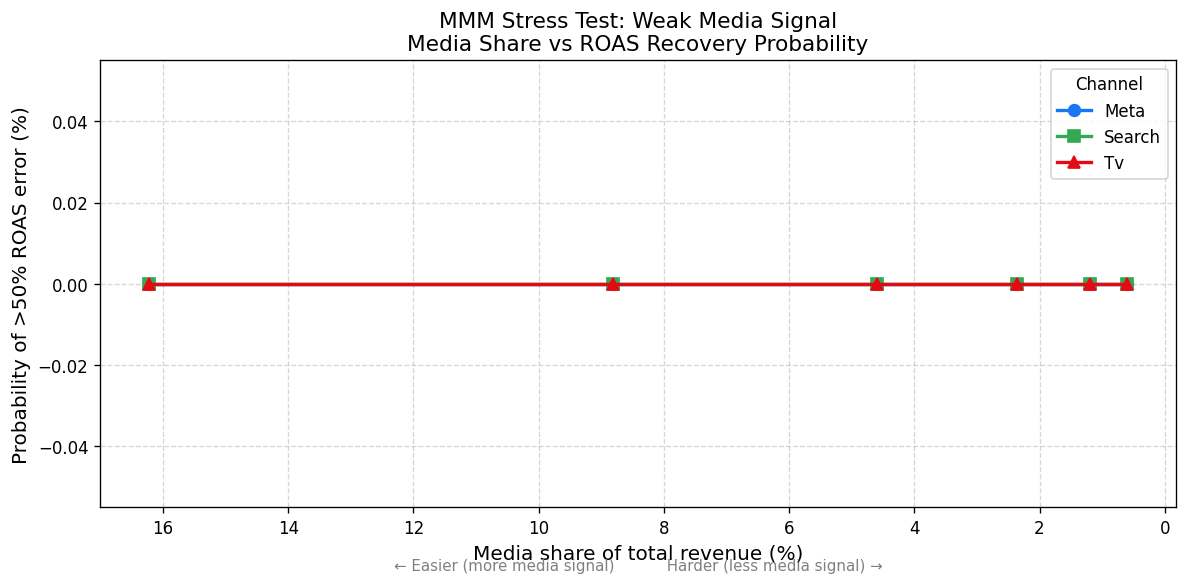


Note: All three channels degrade together — unlike multicollinearity,
where only the correlated channels are affected. Weak signal is symmetric.


In [10]:
channel_styles = {
    "meta":   {"color": "#1877F2", "marker": "o"},
    "search": {"color": "#34A853", "marker": "s"},
    "tv":     {"color": "#E50914", "marker": "^"},
}

fig, ax = plt.subplots(figsize=(10, 5))

for ch in ["meta", "search", "tv"]:
    ch_data = (
        stress_summary[stress_summary["channel"] == ch]
        .sort_values("media_share", ascending=False)
    )
    style = channel_styles[ch]
    ax.plot(
        ch_data["media_share_pct"],
        ch_data["probability_over_50pct_error_pct"],
        marker=style["marker"],
        color=style["color"],
        linewidth=2,
        markersize=7,
        label=ch.title()
    )

ax.invert_xaxis()  # High media share (easy) on left; low media share (hard) on right
ax.set_xlabel("Media share of total revenue (%)", fontsize=12)
ax.set_ylabel("Probability of >50% ROAS error (%)", fontsize=12)
ax.set_title(
    "MMM Stress Test: Weak Media Signal\nMedia Share vs ROAS Recovery Probability",
    fontsize=13
)
ax.legend(title="Channel", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
ax.annotate(
    "← Easier (more media signal)           Harder (less media signal) →",
    xy=(0.5, -0.14), xycoords="axes fraction",
    ha="center", fontsize=9, color="grey"
)
plt.tight_layout()
plt.show()

print("\nNote: All three channels degrade together — unlike multicollinearity,")
print("where only the correlated channels are affected. Weak signal is symmetric.")

## 10. Model fit chart — baseline multiplier vs mean R²

This is the **key paradox** of the weak signal problem.

As the baseline multiplier grows, the model's **prediction accuracy (R²) stays high or even increases** — because the model fits the baseline (trend + seasonality + promotions) very well. The baseline is large, well-specified, and the OLS model captures it precisely.

But the ROAS estimates become increasingly unreliable.

> **R² measures prediction quality, not attribution quality.**
> A high R² does not mean the model has correctly identified which marketing channel drove which revenue.

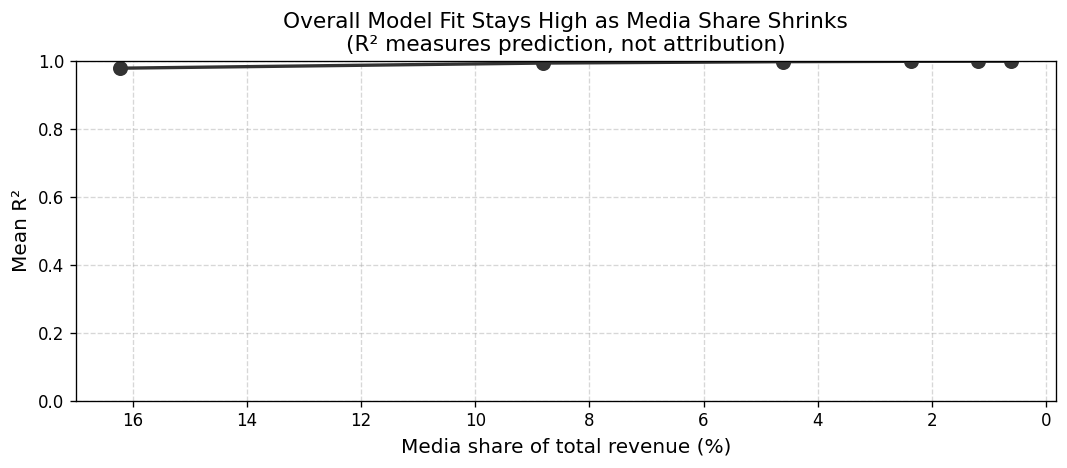


--- Model fit summary by baseline multiplier ---


,baseline_multiplier,media_share_pct,mean_r2
0,1.0000,16.2241,0.9794
1,2.0000,8.8131,0.9945
2,4.0000,4.6029,0.9986
3,8.0000,2.3558,0.9997
4,16.0000,1.1938,0.9999
5,32.0000,0.6018,1.0000


In [11]:
fit_summary = (
    stress_results
    .groupby("baseline_multiplier")
    .agg(
        media_share_pct = ("media_share", lambda x: x.mean() * 100),
        mean_r2         = ("r2",          "mean")
    )
    .reset_index()
    .sort_values("media_share_pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    fit_summary["media_share_pct"],
    fit_summary["mean_r2"],
    marker="o", color="#333333", linewidth=2, markersize=8
)
ax.invert_xaxis()
ax.set_ylim(0, 1)
ax.set_xlabel("Media share of total revenue (%)", fontsize=12)
ax.set_ylabel("Mean R²", fontsize=12)
ax.set_title(
    "Overall Model Fit Stays High as Media Share Shrinks\n"
    "(R² measures prediction, not attribution)",
    fontsize=13
)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("\n--- Model fit summary by baseline multiplier ---")
display(fit_summary)

## 11. ROAS uncertainty — p10 / median / p90 table and ribbon chart

Inspect the full distribution of estimated ROAS across simulations for all three channels.

The ribbon chart shows the 10th–90th percentile interval of estimated ROAS versus the true ROAS (dashed line). A wide ribbon means the model is highly uncertain about the channel's contribution. As the baseline multiplier grows, the ribbons widen dramatically even though the median may remain near the truth.

This illustrates the key distinction between **bias** (is the median right?) and **variance** (how wide is the distribution?).

--- ROAS distribution summary (p10 / median / p90) ---


,baseline_multiplier,channel,media_share,median,p10,p90
0,1.0000,meta,0.1622,1.9952,1.6873,2.3010
1,1.0000,search,0.1622,5.0412,4.5928,5.4231
2,1.0000,tv,0.1622,1.4888,1.3538,1.6462
3,2.0000,meta,0.0881,2.0366,1.7096,2.3251
4,2.0000,search,0.0881,4.9844,4.5869,5.3893
5,2.0000,tv,0.0881,1.5048,1.3771,1.6379
6,4.0000,meta,0.0460,1.9762,1.6912,2.2883
7,4.0000,search,0.0460,4.9959,4.6060,5.4537
8,4.0000,tv,0.0460,1.4891,1.3506,1.6460
9,8.0000,meta,0.0236,1.9814,1.7167,2.2353


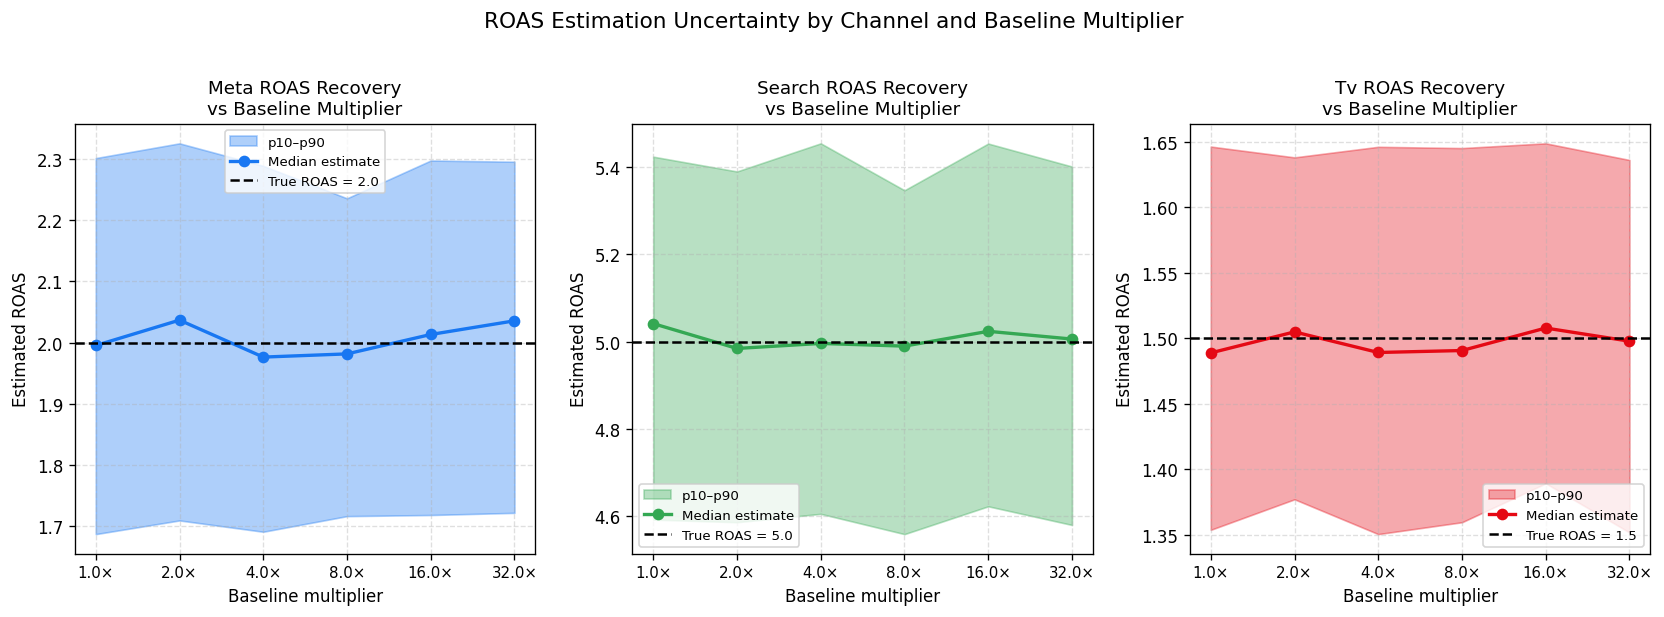

In [12]:
roas_distribution_summary = (
    stress_results
    .groupby(["baseline_multiplier", "channel"])
    .agg(
        media_share = ("media_share",    "mean"),
        median      = ("estimated_roas", "median"),
        p10         = ("estimated_roas", lambda x: np.quantile(x, 0.10)),
        p90         = ("estimated_roas", lambda x: np.quantile(x, 0.90))
    )
    .reset_index()
)

print("--- ROAS distribution summary (p10 / median / p90) ---")
display(roas_distribution_summary)

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for idx, ch in enumerate(["meta", "search", "tv"]):
    ax   = axes[idx]
    ch_d = roas_distribution_summary[roas_distribution_summary["channel"] == ch].copy()
    ch_d = ch_d.sort_values("baseline_multiplier")

    x_labels = ch_d["baseline_multiplier"].astype(str).tolist()
    x_pos    = np.arange(len(x_labels))

    ax.fill_between(x_pos, ch_d["p10"], ch_d["p90"],
                    alpha=0.35, color=list(channel_styles.values())[idx]["color"],
                    label="p10–p90")
    ax.plot(x_pos, ch_d["median"], marker="o",
            color=list(channel_styles.values())[idx]["color"],
            linewidth=2, label="Median estimate")
    ax.axhline(TRUE_ROAS[ch], color="black", linestyle="--", linewidth=1.5,
               label=f"True ROAS = {TRUE_ROAS[ch]}")

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{m}×" for m in ch_d["baseline_multiplier"].tolist()], fontsize=9)
    ax.set_xlabel("Baseline multiplier", fontsize=10)
    ax.set_ylabel("Estimated ROAS", fontsize=10)
    ax.set_title(f"{ch.title()} ROAS Recovery\nvs Baseline Multiplier", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("ROAS Estimation Uncertainty by Channel and Baseline Multiplier",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 12. Save results to CSV

In [13]:
stress_results.to_csv("mmm_stress_test_05_raw_results.csv", index=False)
print(f"Saved raw results : mmm_stress_test_05_raw_results.csv  ({len(stress_results):,} rows)")

stress_summary.to_csv("mmm_stress_test_05_summary.csv", index=False)
print(f"Saved summary     : mmm_stress_test_05_summary.csv  ({len(stress_summary)} rows)")

Saved raw results : mmm_stress_test_05_raw_results.csv  (5,400 rows)
Saved summary     : mmm_stress_test_05_summary.csv  (18 rows)
